



# Analisis de los datos climaticos por hora

In [1]:
!python -m pip install statsmodels
!python -m pip install seaborn
!python -m pip install pandas numpy matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.5 MB 16.4 MB/s eta 0:00:01
   ----

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('wunderground_ezeiza_daily_2014_2026.csv')
# Ver las primeras filas
print("Las primeras filas son: \n")
print(df.head())
print("\n")

Las primeras filas son: 

         date  year  month  day  observation_index observation_time  \
0  2014-01-01  2014      1    1                  1         11:30 PM   
1  2014-01-01  2014      1    1                  2         12:30 AM   
2  2014-01-01  2014      1    1                  3          1:30 AM   
3  2014-01-01  2014      1    1                  4          2:30 AM   
4  2014-01-01  2014      1    1                  5          3:30 AM   

   temperature_f  dew_point_f  humidity_pct wind_direction  wind_speed_mph  \
0             79           57            47              N               3   
1             77           64            65             NE               5   
2             79           66            65            NNE               5   
3             68           63            83           CALM               0   
4             68           63            83            WNW               2   

   wind_gust_mph  pressure_in  precip_in condition  \
0              0        

Los estadisticos principales son:

In [19]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Combina el dia con la hora observada para construir una marca temporal completa
df["observation_datetime"] = pd.to_datetime(
    df["date"].dt.strftime("%Y-%m-%d") + " " + df["observation_time"].str.strip(),
    format="%Y-%m-%d %I:%M %p",
    errors="coerce",
)

df = df.dropna(subset=["observation_datetime"]).sort_values(
    ["observation_datetime", "observation_index"],
    kind="mergesort",
).reset_index(drop=True)

# Variables auxiliares para modelos que necesitan orden temporal explicito
df["time_idx"] = np.arange(len(df))
df["hour"] = df["observation_datetime"].dt.hour
df["minute"] = df["observation_datetime"].dt.minute


In [20]:
# Ver estadísticas descriptivas
print("Los estadisticos principales son:")
print(df.describe())

Los estadisticos principales son:
                                date           year          month  \
count                         118320  118320.000000  118320.000000   
mean   2020-01-30 02:24:16.064908544    2019.587956       6.428524   
min              2014-01-01 00:00:00    2014.000000       1.000000   
25%              2017-01-08 00:00:00    2017.000000       3.000000   
50%              2020-01-25 00:00:00    2020.000000       6.000000   
75%              2023-02-17 00:00:00    2023.000000       9.000000   
max              2026-03-27 00:00:00    2026.000000      12.000000   
std                              NaN       3.530093       3.430459   

                day  observation_index  temperature_f    dew_point_f  \
count  118320.00000      118320.000000  118320.000000  118320.000000   
mean       15.70366          14.100904      62.812010      52.538227   
min         1.00000           1.000000       0.000000       0.000000   
25%         8.00000           7.000000      54.

In [21]:
# Valores nulos
print("Los valores nulos son: \n")
print(df.isnull().sum())

Los valores nulos son: 

date                      0
year                      0
month                     0
day                       0
observation_index         0
observation_time          0
temperature_f             0
dew_point_f               0
humidity_pct              0
wind_direction          195
wind_speed_mph            0
wind_gust_mph             0
pressure_in               0
precip_in                 0
condition                 0
source_url                0
observation_datetime      0
time_idx                  0
hour                      0
minute                    0
dtype: int64


In [22]:
directions = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

direction_to_degrees = {
    direction: i * 22.5
    for i, direction in enumerate(directions)
}

df["wind_dir_missing"] = df["wind_direction"].isna().astype(int)

deg = df["wind_direction"].map(direction_to_degrees)
rad = np.deg2rad(deg)

df["wind_dir_sin"] = np.sin(rad)
df["wind_dir_cos"] = np.cos(rad)

df["wind_dir_sin"] = df["wind_dir_sin"].fillna(0.0)
df["wind_dir_cos"] = df["wind_dir_cos"].fillna(0.0)

In [23]:
cond = df["condition"].fillna("").str.lower()

df["cond_fair"] = cond.str.contains(r"\bfair\b").astype(int)
df["cond_cloudy"] = cond.str.contains(r"cloudy").astype(int)
df["cond_partly_cloudy"] = cond.str.contains(r"partly cloudy").astype(int)
df["cond_mostly_cloudy"] = cond.str.contains(r"mostly cloudy").astype(int)

df["cond_rain"] = cond.str.contains(r"\brain\b").astype(int)
df["cond_drizzle"] = cond.str.contains(r"drizzle").astype(int)
df["cond_shower"] = cond.str.contains(r"shower|showers").astype(int)

df["cond_thunder"] = cond.str.contains(r"thunder|t-storm").astype(int)
df["cond_fog"] = cond.str.contains(r"\bfog\b").astype(int)
df["cond_mist"] = cond.str.contains(r"\bmist\b").astype(int)
df["cond_haze"] = cond.str.contains(r"\bhaze\b").astype(int)
df["cond_smoke"] = cond.str.contains(r"\bsmoke\b").astype(int)
df["cond_dust"] = cond.str.contains(r"dust").astype(int)

df["cond_windy"] = cond.str.contains(r"windy").astype(int)
df["cond_heavy"] = cond.str.contains(r"heavy").astype(int)
df["cond_light"] = cond.str.contains(r"light").astype(int)
df["cond_vicinity"] = cond.str.contains(r"vicinity").astype(int)


In [24]:
df = df.drop(columns=["wind_gust_mph", "precip_in", "date", "year", "month", "day", "observation_index", "observation_time", "condition", "wind_direction" ])

In [28]:
first_cols = ["time_idx", "hour", "minute", "observation_datetime"]
df = df[first_cols + [col for col in df.columns if col not in first_cols]]


In [29]:

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(df.head())


   time_idx  hour  minute observation_datetime  temperature_f  dew_point_f  \
0         0     0      30  2014-01-01 00:30:00             77           64   
1         1     1      30  2014-01-01 01:30:00             79           66   
2         2     2      30  2014-01-01 02:30:00             68           63   
3         3     3      30  2014-01-01 03:30:00             68           63   
4         4     4      30  2014-01-01 04:30:00             72           68   

   humidity_pct  wind_speed_mph  pressure_in  \
0            65               5        29.61   
1            65               5        29.61   
2            83               0        29.61   
3            83               2        29.61   
4            88               3        29.61   

                                                                source_url  \
0  https://www.wunderground.com/history/daily/ar/ezeiza/SAEZ/date/2014-1-1   
1  https://www.wunderground.com/history/daily/ar/ezeiza/SAEZ/date/2014-1-1   
2  https

In [30]:
# Boxplot para cada columna numerica
df.select_dtypes(include="number").boxplot(figsize=(16,8), rot=90)

<Axes: >

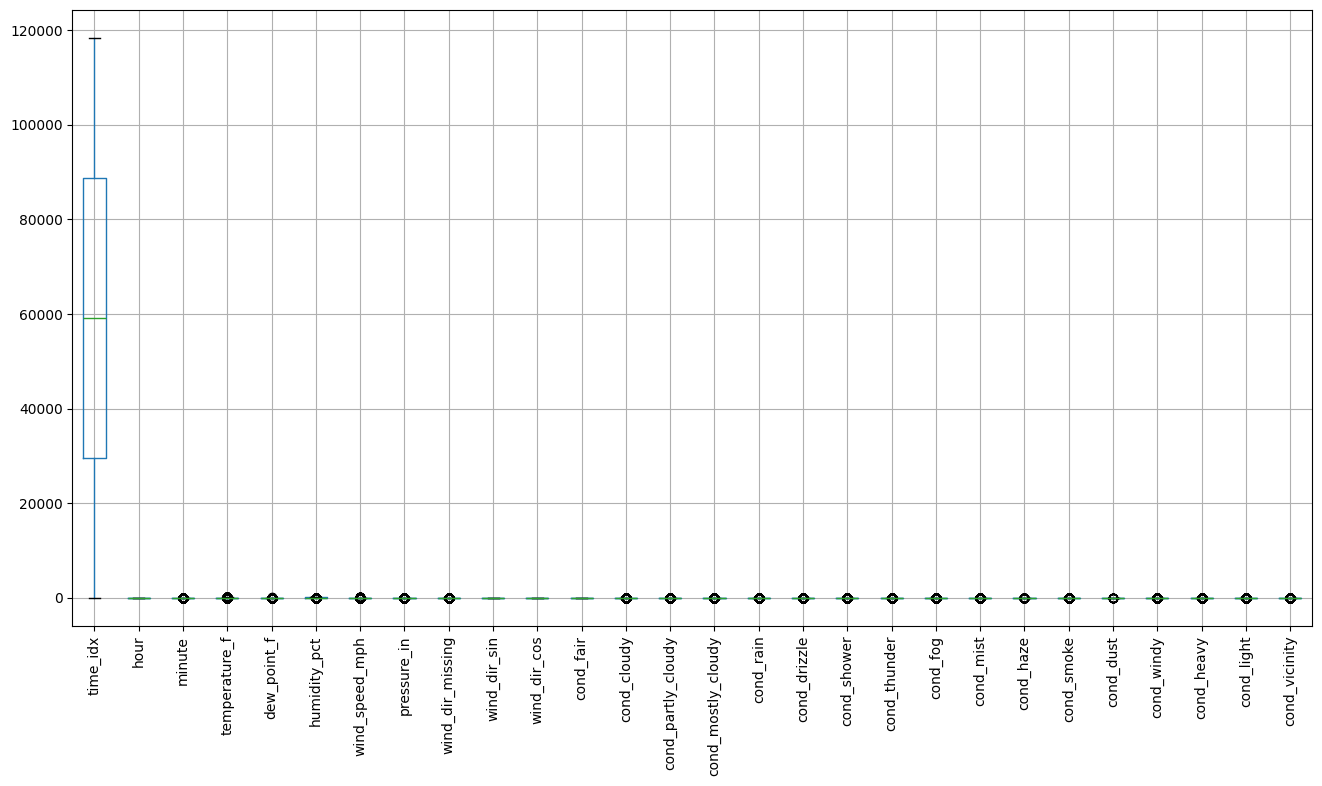

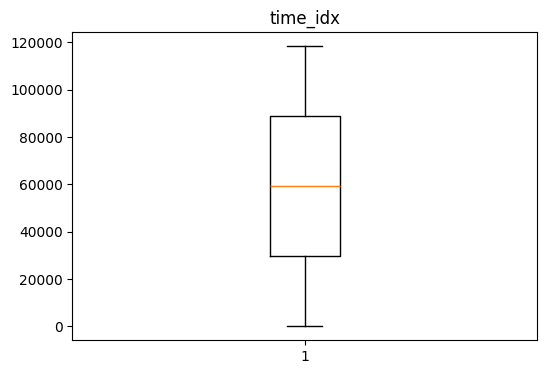

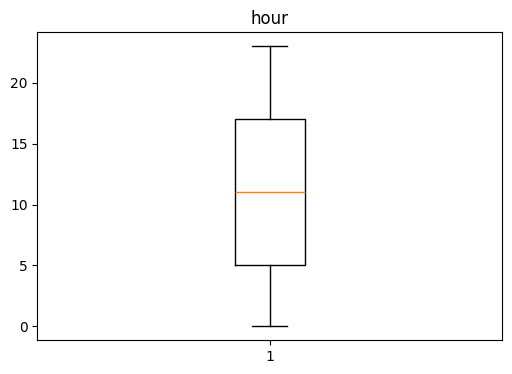

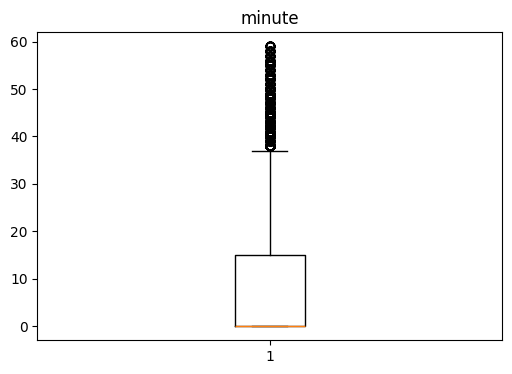

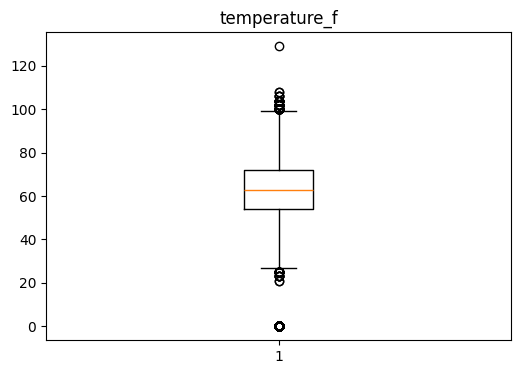

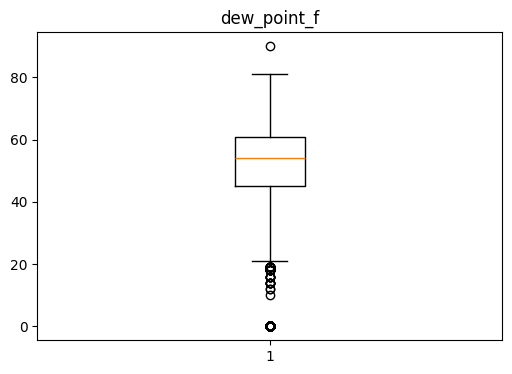

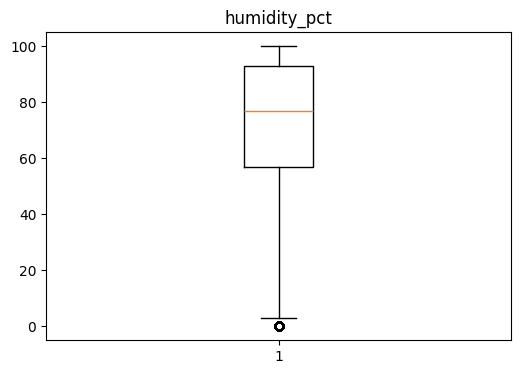

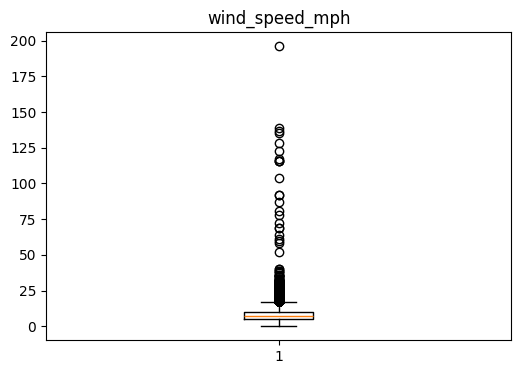

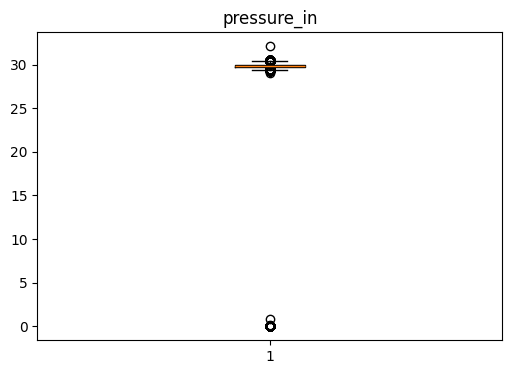

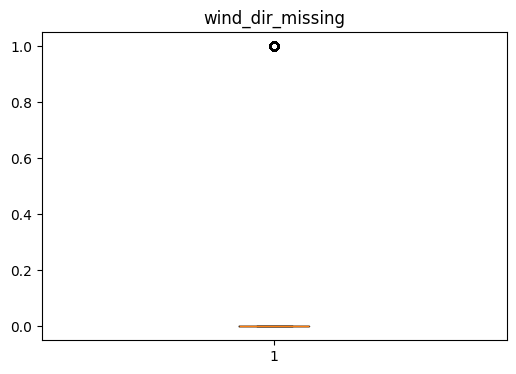

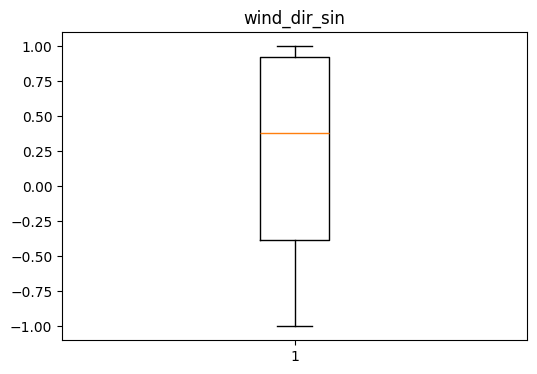

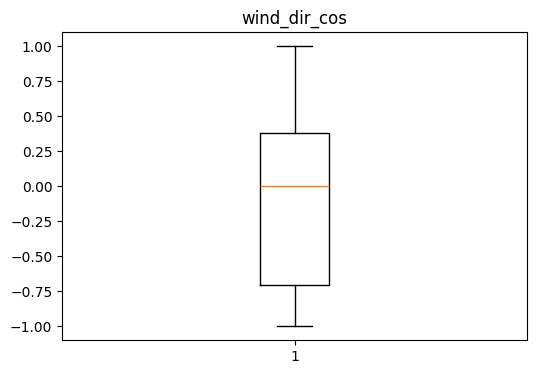

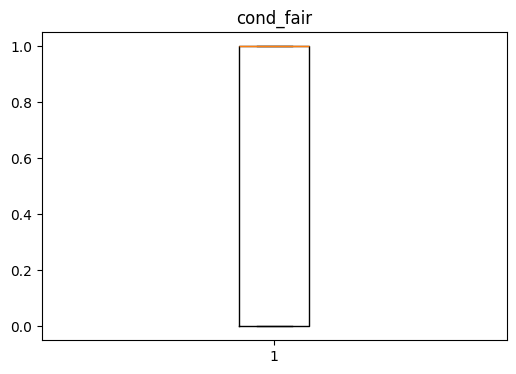

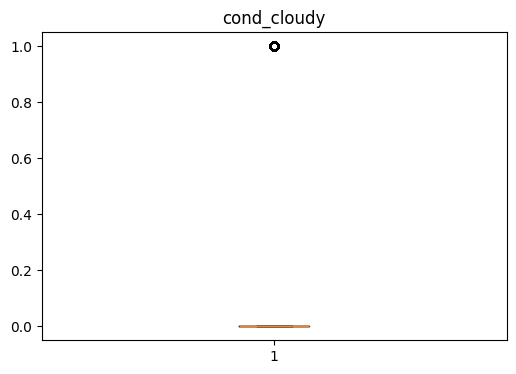

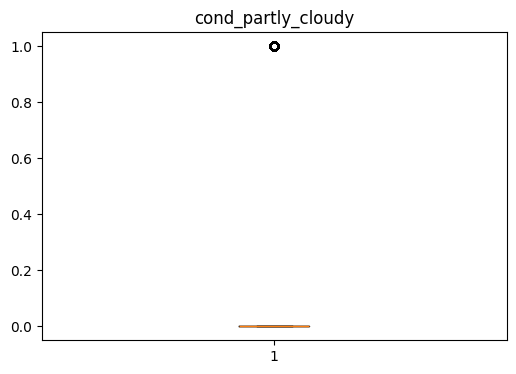

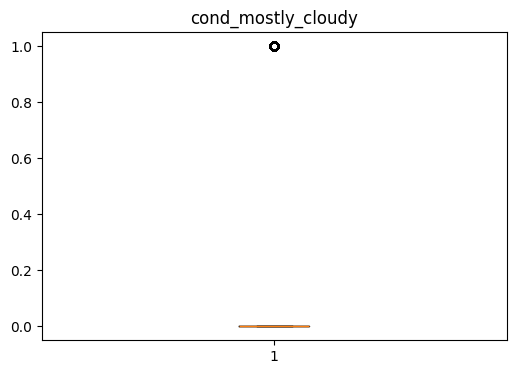

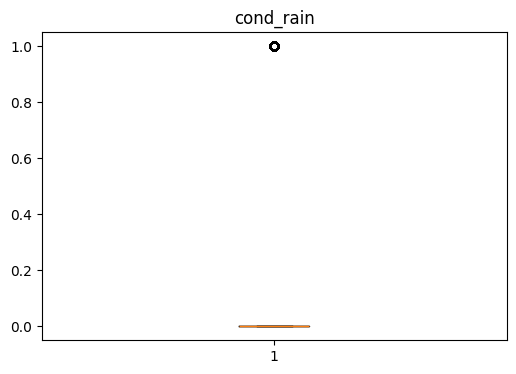

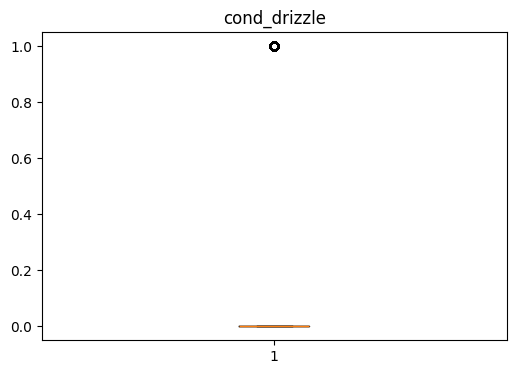

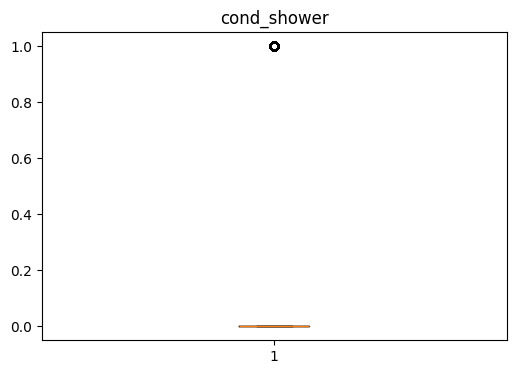

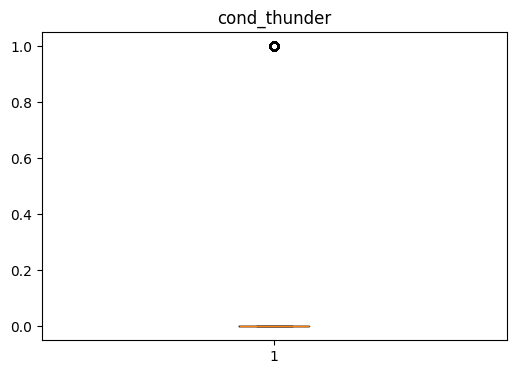

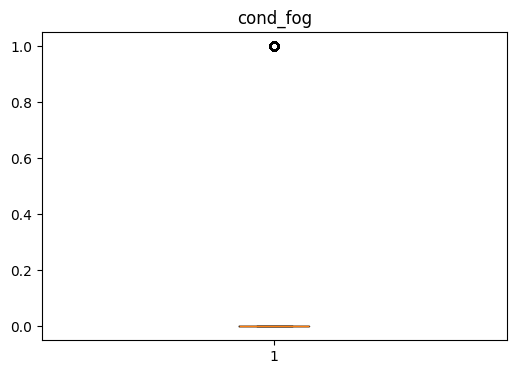

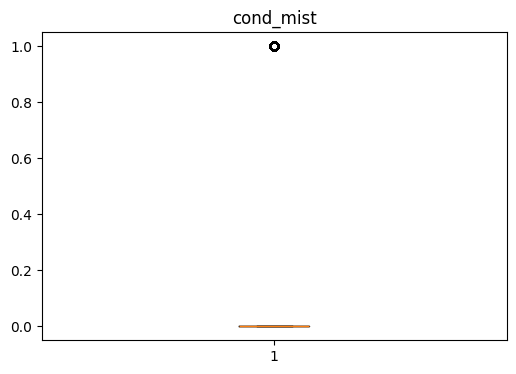

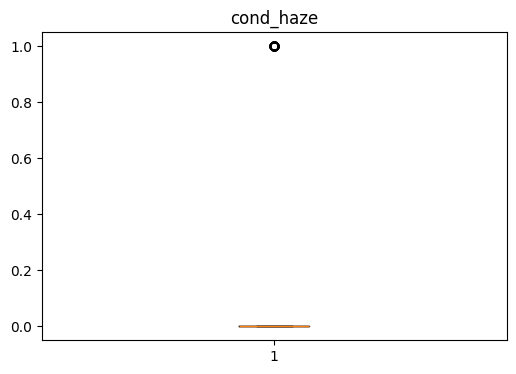

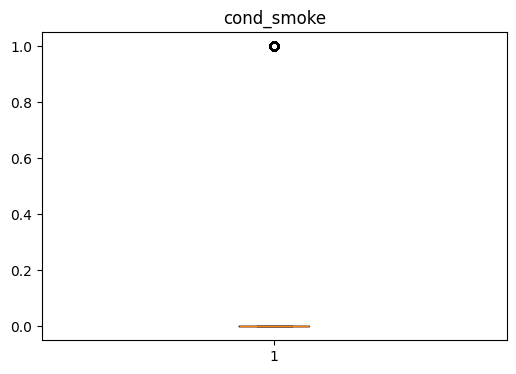

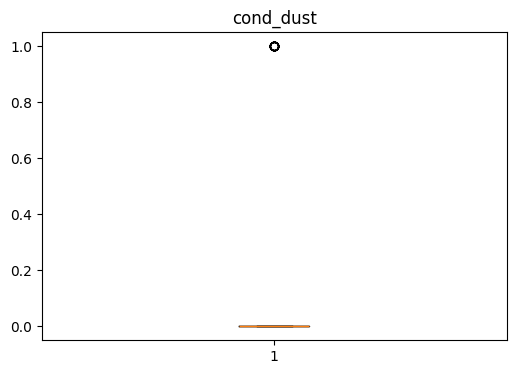

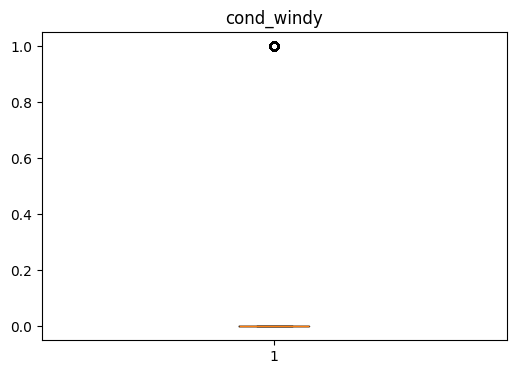

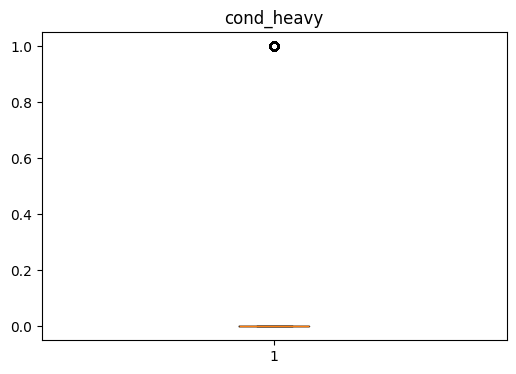

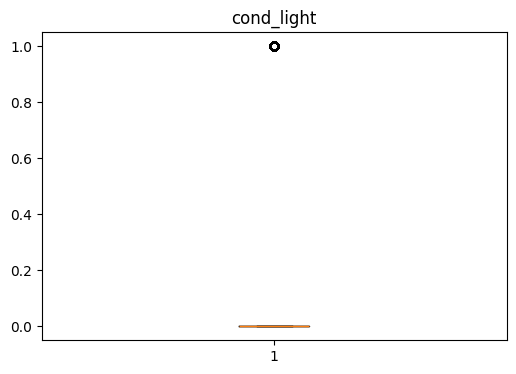

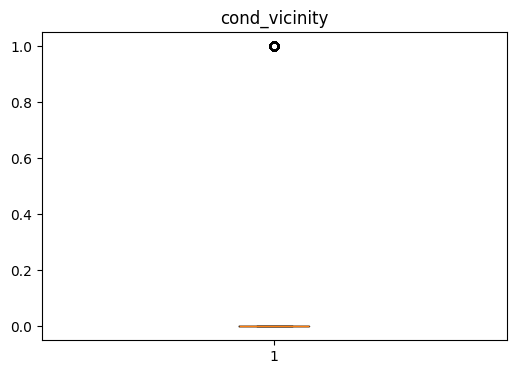

In [31]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [32]:
# Para temperature_f
mask = df["temperature_f"] > 110
df["temperature_f"] = df["temperature_f"].mask(mask).interpolate(limit_direction="both")

# Para temperature_f
mask = df["temperature_f"] < 30
df["temperature_f"] = df["temperature_f"].mask(mask).interpolate(limit_direction="both")

# Para dew_point_f
mask = df["dew_point_f"] > 83
df["dew_point_f"] = df["dew_point_f"].mask(mask).interpolate(limit_direction="both")

# Para dew_point_f
mask = df["dew_point_f"] < 10
df["dew_point_f"] = df["dew_point_f"].mask(mask).interpolate(limit_direction="both")

# Para humidity_pct
mask = df["humidity_pct"] < 2
df["humidity_pct"] = df["humidity_pct"].mask(mask).interpolate(limit_direction="both")

# Para wind_speed_mph
mask = df["wind_speed_mph"] < 60
df["wind_speed_mph"] = df["wind_speed_mph"].mask(mask).interpolate(limit_direction="both")

# Para pressure_in
mask = df["pressure_in"] > 31.5
df["pressure_in"] = df["pressure_in"].mask(mask).interpolate(limit_direction="both")

# Para pressure_in
mask = df["pressure_in"] < 26.5
df["pressure_in"] = df["pressure_in"].mask(mask).interpolate(limit_direction="both")

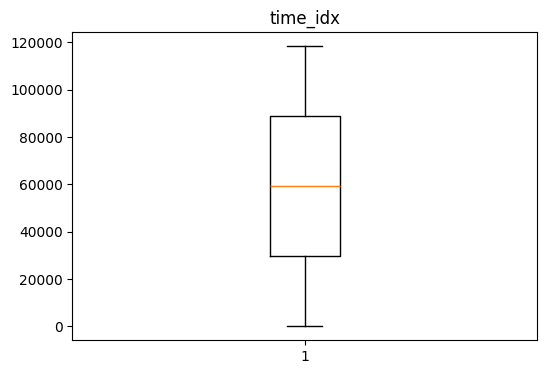

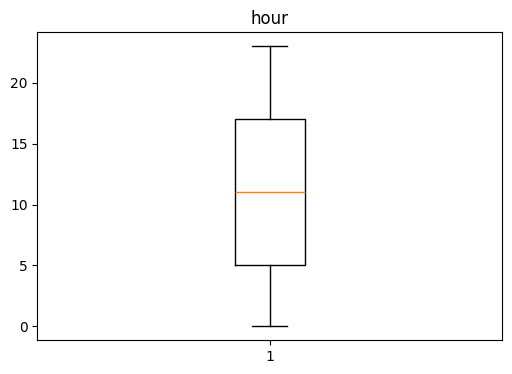

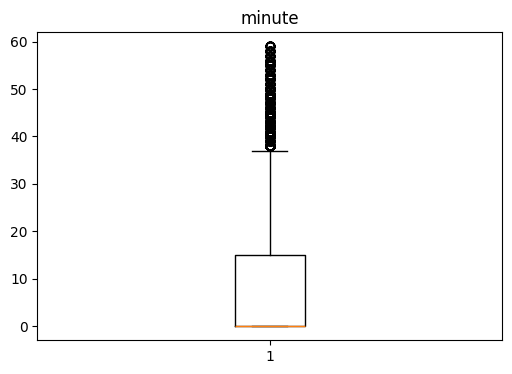

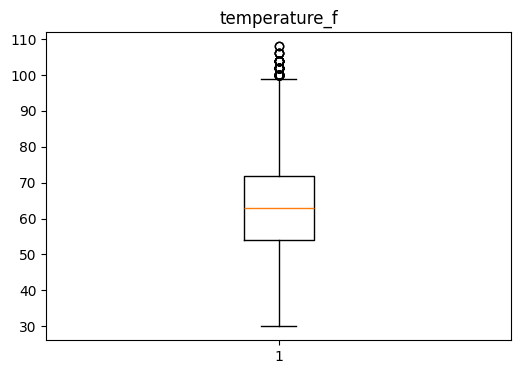

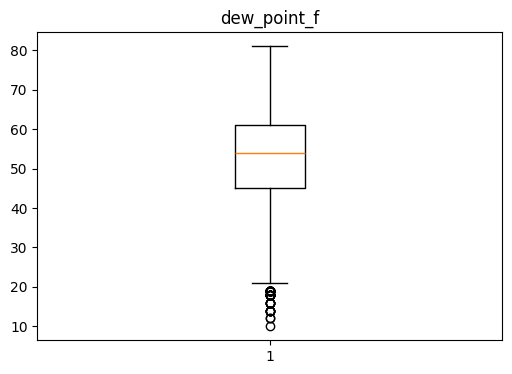

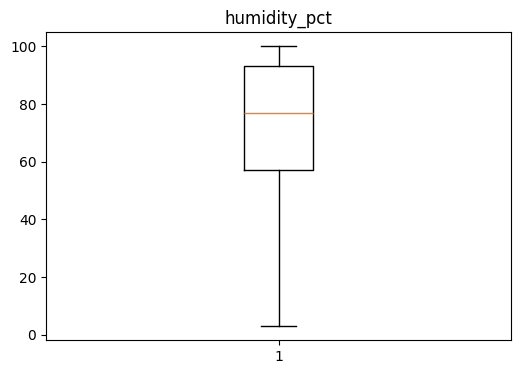

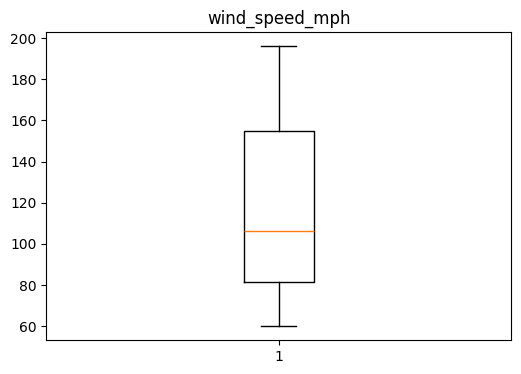

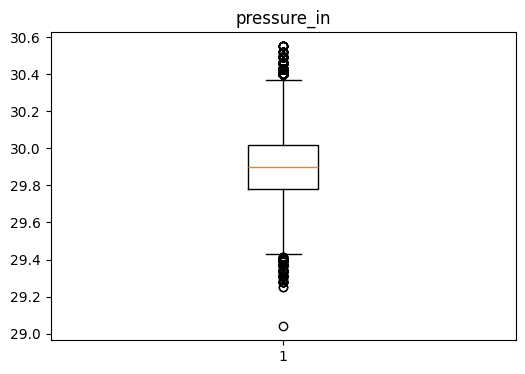

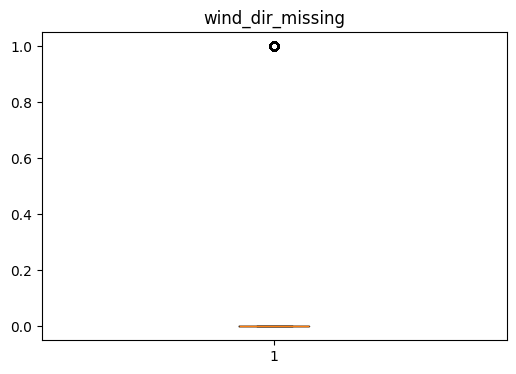

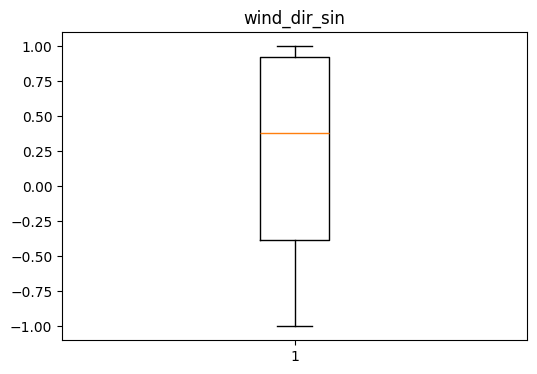

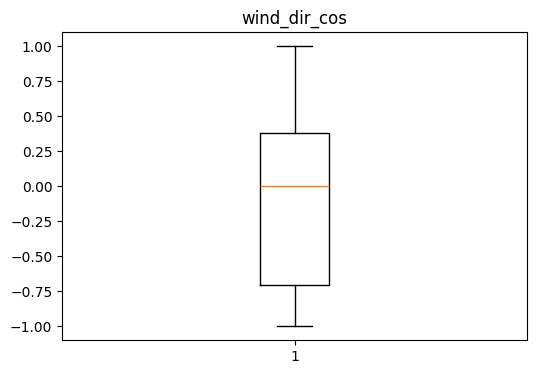

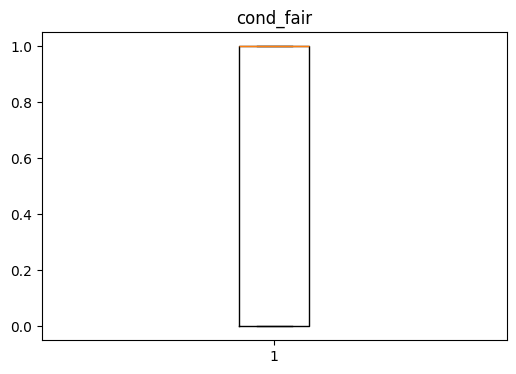

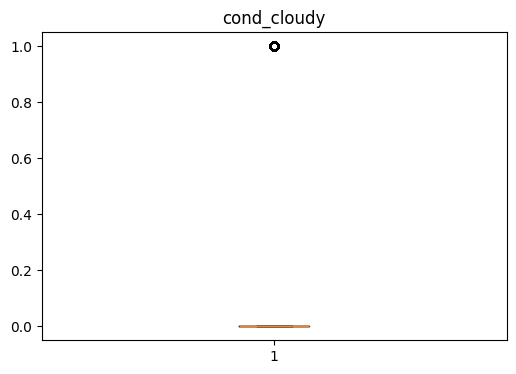

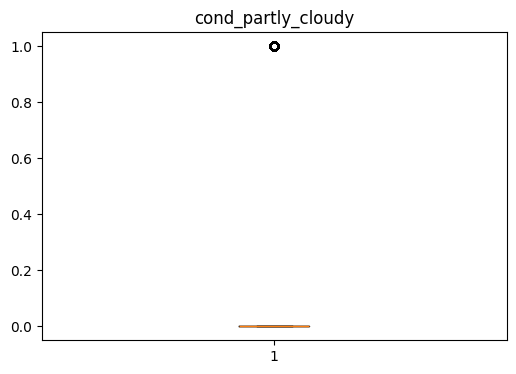

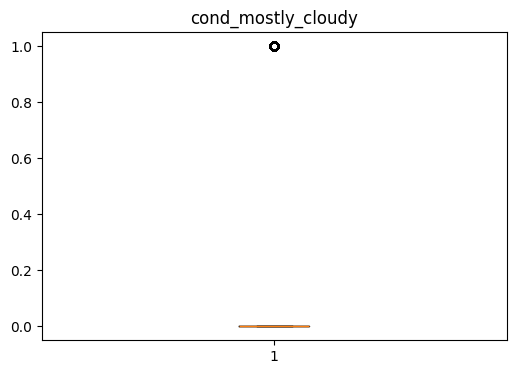

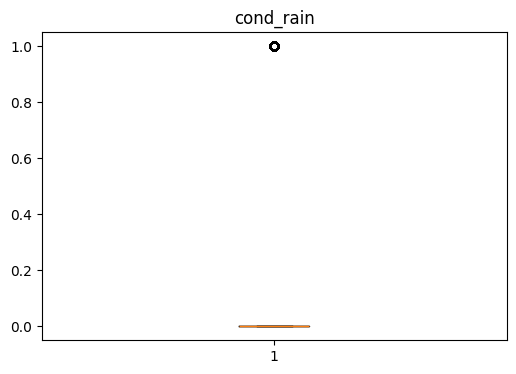

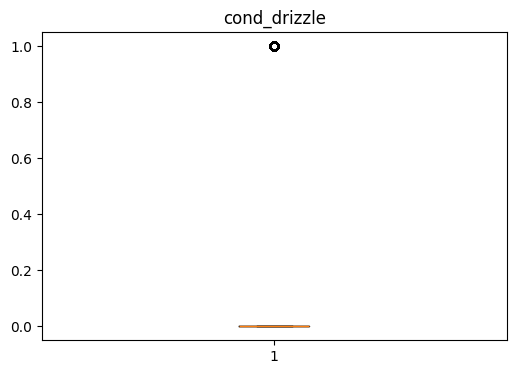

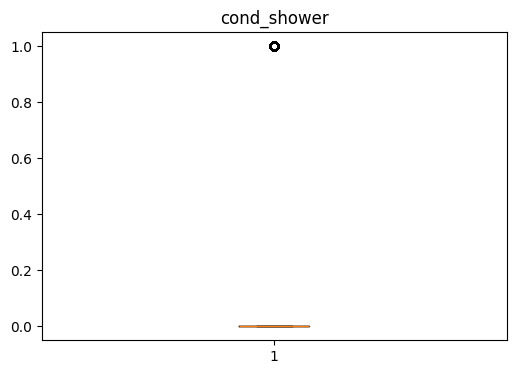

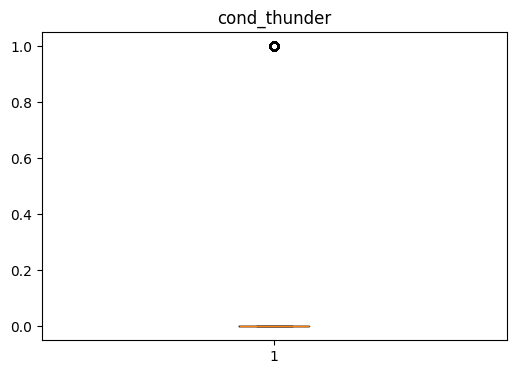

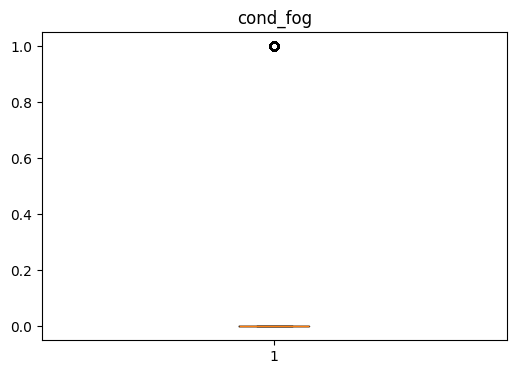

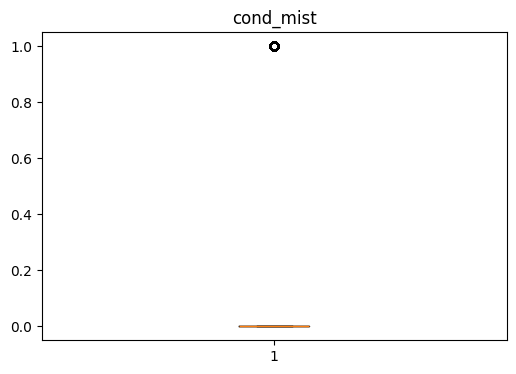

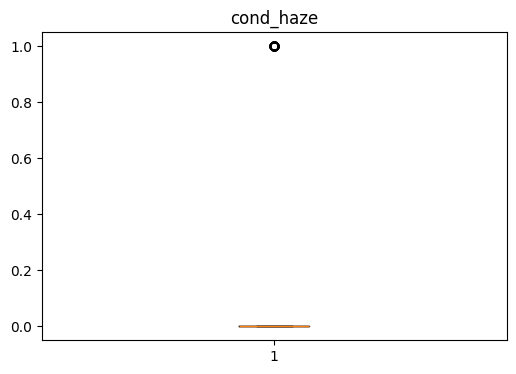

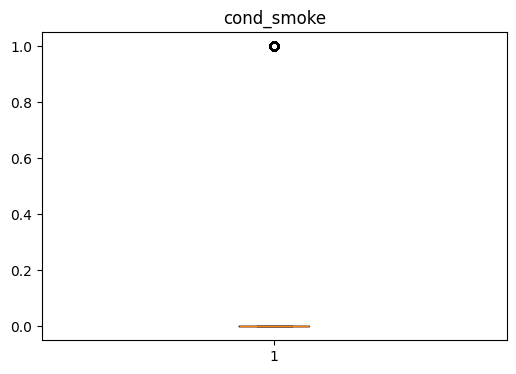

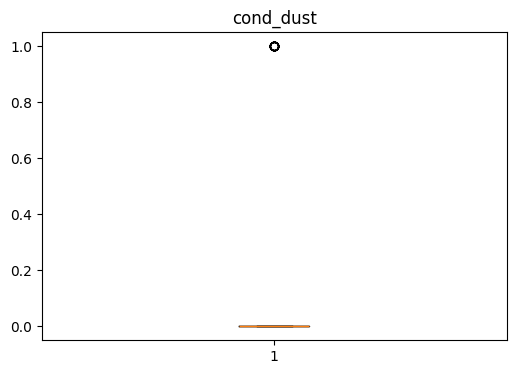

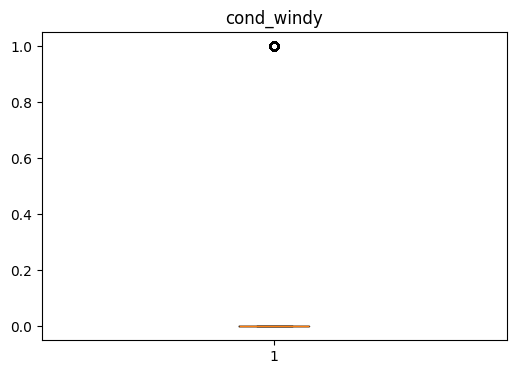

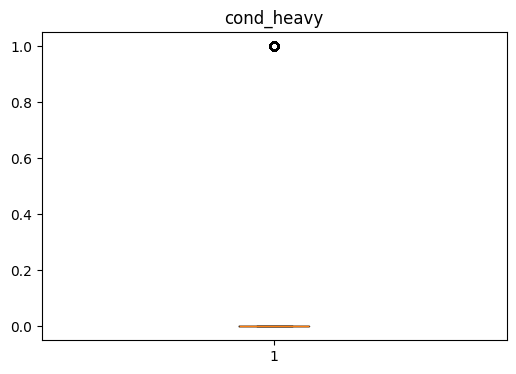

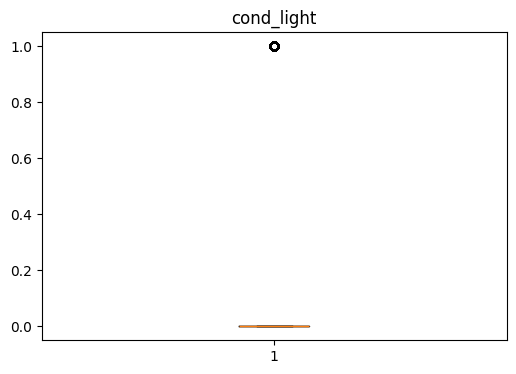

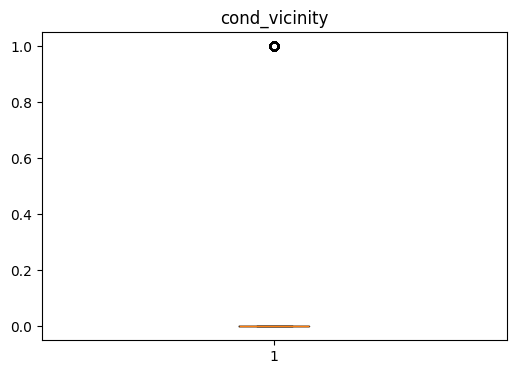

In [33]:
# Boxplot para cada columna numerica
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

Como se puede apreciar, la mayoria de valores atipicos desaparecieron

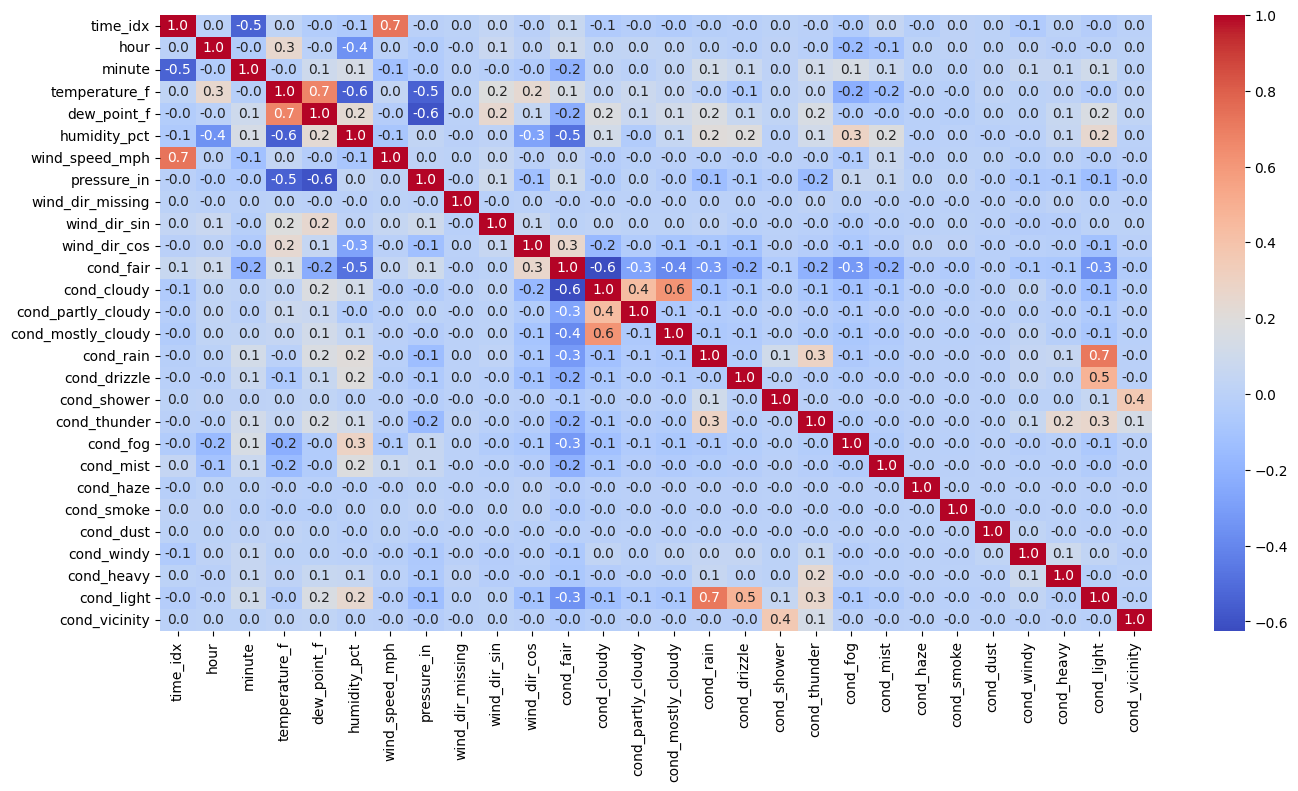

In [37]:
# Matriz de correlaccion con seaborn
corr_df = df.select_dtypes(include="number").corr()
plt.figure(figsize=(16,8))
sns.heatmap(corr_df, annot=True, cmap = "coolwarm", fmt = ".1f")
plt.show()

La matriz muestra que, en general, predominan correlaciones débiles, por lo que no hay una multicolinealidad fuerte entre la mayoría de las variables; las relaciones más claras y físicamente coherentes son temperature_f–dew_point_f con correlación positiva alta (r≈0.7), y las correlaciones negativas de temperature_f–humidity_pct (r≈-0.6), dew_point_f–pressure_in (r≈-0.6) y temperature_f–pressure_in (r≈-0.5). En las variables de condición climática aparece una dependencia estructural esperable por el one-hot encoding, por ejemplo cond_cloudy–cond_mostly_cloudy (r≈0.6), cond_fair–cond_cloudy (r≈-0.6) y cond_rain–cond_light (r≈0.7)

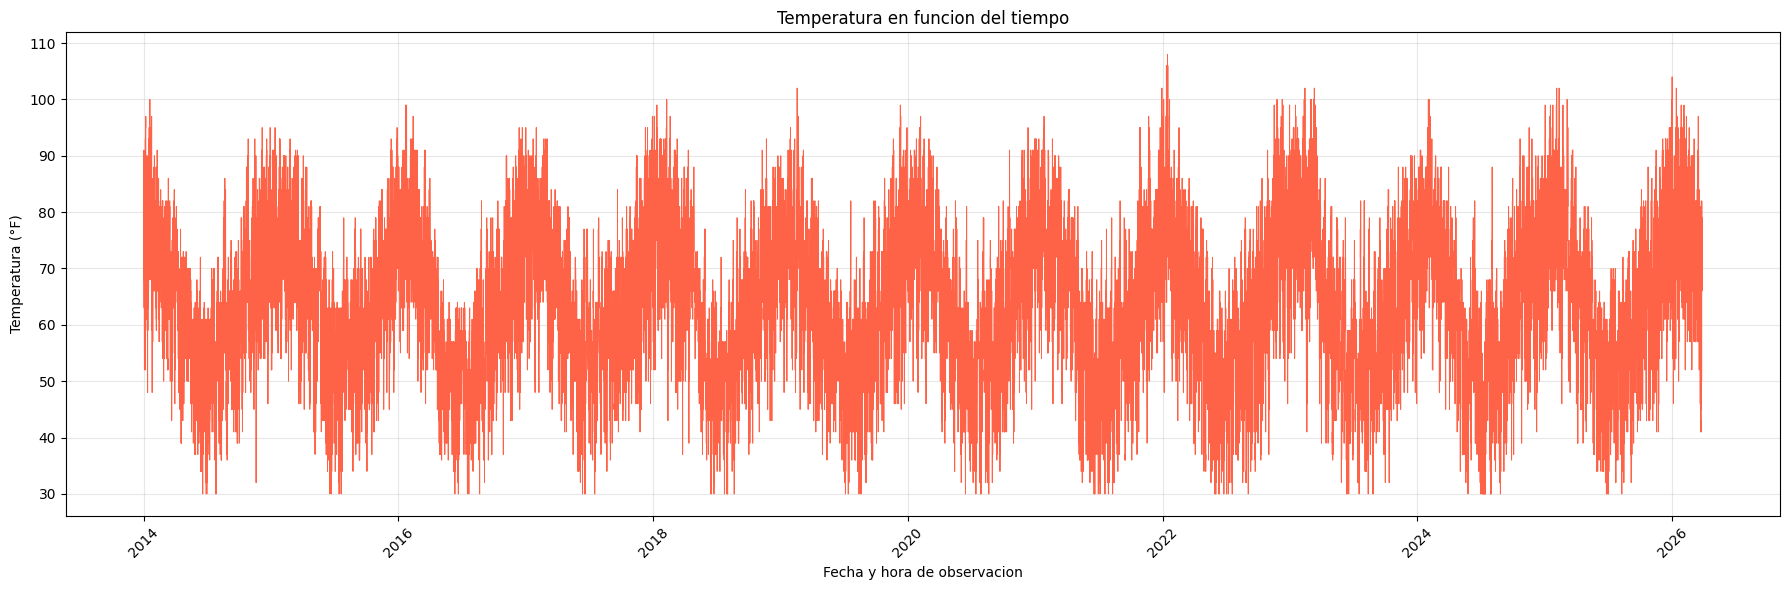

In [38]:
df_plot = (
    df.dropna(subset=["observation_datetime", "temperature_f"])
      .sort_values("observation_datetime")
)

plt.figure(figsize=(18, 6))
plt.plot(
    df_plot["observation_datetime"],
    df_plot["temperature_f"],
    color="tomato",
    linewidth=0.7
)

plt.title("Temperatura en funcion del tiempo")
plt.xlabel("Fecha y hora de observacion")
plt.ylabel("Temperatura (°F)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
